In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [18]:
iris = datasets.load_iris()
X = iris.data
y = iris.target.copy()

In [19]:
y[y != 0] = 1  # 转化为二分类问题

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=666)
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_predict = logistic_regression.predict(X_test)
y_predict

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [21]:
decision_scores = logistic_regression.decision_function(X_test)  # 计算测试集样本到分类边界的距离得分
decision_scores

array([ 4.52818505,  6.87901472,  1.76728414,  6.52488998, -3.69893489,
        3.62555304,  4.5641345 ,  6.91106486,  5.03499692,  4.3292245 ,
        4.65382011, -3.43985382, -3.38750347, -3.39712028,  9.14590416,
        3.55830077, -5.19913952,  8.64478135,  7.05911342,  7.24100241,
        5.13254176, -3.758013  , 11.76868021, -3.89433573,  4.27903572,
        4.01351394, -4.2488403 ,  3.78927124,  8.75367646,  9.69578918,
       -4.01142913, -3.69538324,  3.69140718,  7.14170805,  1.08284202,
        5.36638089,  7.40154878, 10.56568001])

In [22]:
from sklearn.metrics import precision_score  # 导入精确率和召回率评价指标
from sklearn.metrics import recall_score
precision_scores = []  # 保存不同阈值下的精确率
recall_scores = []     # 保存不同阈值下的召回率
thresholds = np.sort(decision_scores)  # 将决策得分排序，作为不同的分类阈值
for threshold in thresholds:  # 遍历每一个分类阈值
    y_predict = np.array(decision_scores >= threshold, dtype="int")  # 得分大于等于阈值预测为1，否则预测为0
    precision = precision_score(y_test, y_predict)  # 计算精确率
    recall = recall_score(y_test, y_predict)        # 计算召回率
    precision_scores.append(precision)              # 保存精确率
    recall_scores.append(recall)                    # 保存召回率

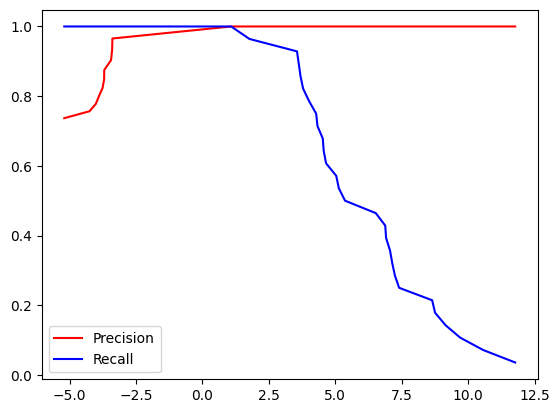

In [23]:
plt.plot(thresholds, precision_scores, color="r", label="Precision")  # 绘制不同阈值下的精确率曲线
plt.plot(thresholds, recall_scores, color="b", label="Recall")  # 绘制不同阈值下的召回率曲线
plt.legend()
plt.show()

### Precision-Recall 曲线

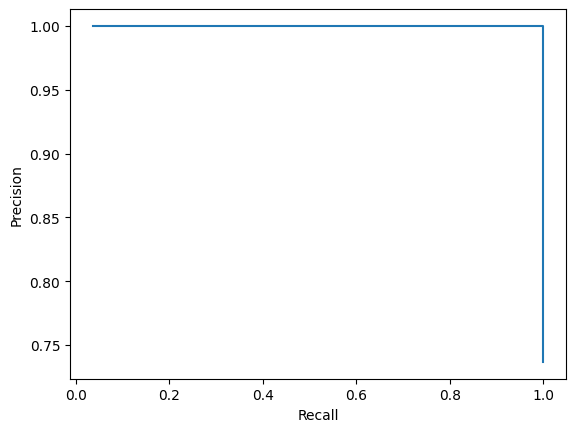

In [24]:
plt.plot(recall_scores, precision_scores)  # 绘制 Precision-Recall 曲线
plt.xlabel("Recall")  # 设置横轴为召回率
plt.ylabel("Precision")  # 设置纵轴为精确率
plt.show()

### scikit-learn中的PR曲线

In [25]:
from sklearn.metrics import precision_recall_curve
precision_recall_curve(y_test, decision_scores)

(array([0.73684211, 0.75675676, 0.77777778, 0.8       , 0.82352941,
        0.84848485, 0.875     , 0.90322581, 0.93333333, 0.96551724,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        ]),
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 0.96428571, 0.92857143, 0.89285714, 0.85714286,
        0.82142857, 0.78571429, 0.75      , 0.71428571, 0.67857143,
        0.64285714, 0.60714286, 0.57142857, 0.53571429, 0.5       ,
        0.46428571, 0.42857143, 0.39285714, 0.35714286, 0.32142857,
        0.28571429, 0.25      , 0.21428571, 0.17857143, 0.

In [26]:
precision_scores, recall_scores, thresholds = precision_recall_curve(y_test, decision_scores)

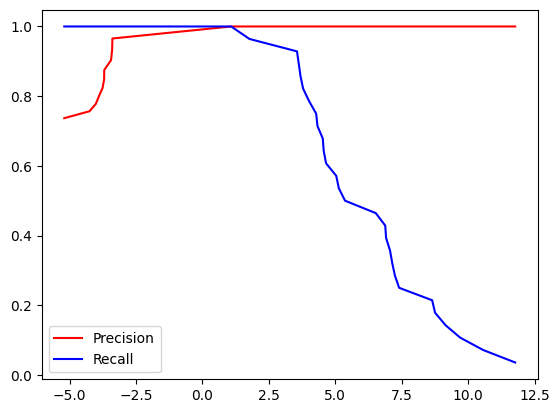

In [27]:
# 绘制不同阈值下的 Precision 曲线，precision_scores 比 thresholds 多 1 个元素，所以去掉最后一个
plt.plot(thresholds, precision_scores[:-1], color="r", label="Precision")
# 绘制不同阈值下的 Recall 曲线，recall_scores 比 thresholds 多 1 个元素，所以去掉最后一个
plt.plot(thresholds, recall_scores[:-1], color="b", label="Recall")
plt.legend()
plt.show()

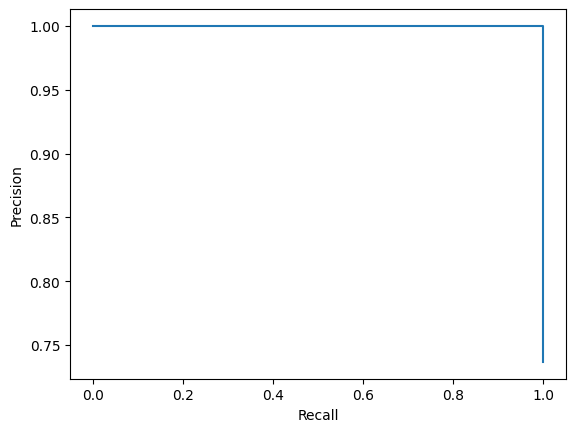

In [28]:
plt.plot(recall_scores, precision_scores)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### scikit-learn中的ROC曲线

In [29]:
from sklearn.metrics import roc_curve
roc_curve(y_test, decision_scores)

(array([0., 0., 0., 1.]),
 array([0.        , 0.03571429, 1.        , 1.        ]),
 array([        inf, 11.76868021,  1.08284202, -5.19913952]))

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)

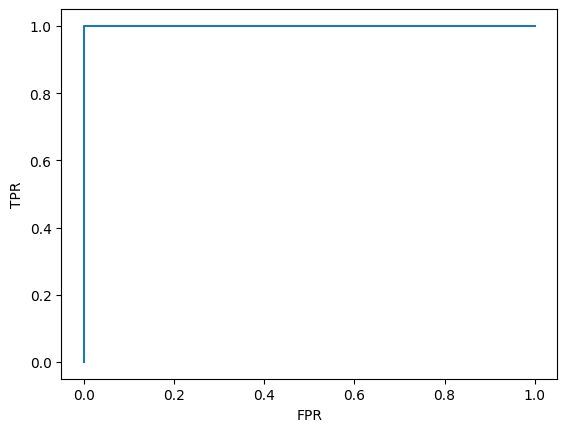

In [31]:
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

### AUC

In [32]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, decision_scores)
auc

1.0